## Import Libraries

In [1]:
import os

os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [2]:
import numpy as np

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## Prepare train dataset

In [3]:
# Transform to turn into tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081,)) # mean y std
])

In [4]:
# Load the dataset and normalize it
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

## Prepare test dataset

In [5]:
transform_test = transforms.ToTensor()

In [6]:
# Load the test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

## Data Loaders

In [7]:
# DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=1028,
    num_workers=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=2056,
    num_workers=4,
    shuffle=True,
    drop_last=False
)

## Feed Forward Network 

In [8]:
import torch

print(f"¿GPU disponible?: {torch.cuda.is_available()}")
print(f"Nombre de la GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Ninguna'}")

¿GPU disponible?: True
Nombre de la GPU: AMD Radeon RX 6600


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cuda


In [10]:
def createTheMNISTNet(optimizerAlgo, learningRate):

    class mnistNet(nn.Module):
        def __init__(self):
            super().__init__()

            # input layer
            self.input = nn.Linear(784,64) # 784 pixels

            # hidden layer
            self.fc1 = nn.Linear(64,32)
            self.fc2 = nn.Linear(32,32)

            # output layer
            self.output = nn.Linear(32,10)

        def forward(self,x):
            x = x.view(x.shape[0], -1)
            
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            x = F.relu( self.fc2(x) )
            
            return self.output(x)

    net = mnistNet()

    lossfun = nn.CrossEntropyLoss()

    optifun = getattr( torch.optim, optimizerAlgo )
    optimizer = optifun(net.parameters(), lr=learningRate)

    return net, lossfun, optimizer

## Training

In [11]:
def function2trainTheModel(optimizerAlgo, learningRate):

    numepochs = 60

    net, lossfun, optimizer = createTheMNISTNet(optimizerAlgo, learningRate)
    net.to(device)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ===== Train =====
        batchAcc = []
        batchLoss = []
        for X,y in train_loader:

            X, y = X.to(device), y.to(device)
            
            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # back
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # loss
            batchLoss.append( loss.item() )

            # accuracy
            matches = torch.argmax(yHat, axis=1) == y # predictions
            matchesNumeric = matches.float() # to numeric
            accuracyPct = 100*torch.mean(matchesNumeric) # pct of mean
            batchAcc.append( accuracyPct.item() ) # add

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss)

        # ===== Test =====
        X,y = next(iter(test_loader))
        X, y = X.to(device), y.to(device)
        yHat = net(X)

        acc = 100*torch.mean( (torch.argmax(yHat, axis=1)==y).float() )
        testAcc.append( acc.item() )
        
        print(f'Epoch: {epochi} \f trainAcc: {trainAcc[epochi]} \f testAcc: {testAcc[epochi]}')

    return trainAcc, testAcc, losses, net

In [13]:
learningRates = np.logspace(np.log10(.0001), np.log10(.1), 6)
optimTypes = ['SGD', 'RMSprop', 'Adam']

finalPerformance = np.zeros( (len(learningRates),len(optimTypes)) )

for idx_o, opto in enumerate(optimTypes):
    for idx_l, lr in enumerate(learningRates):
        trainAcc, testAcc, losses, net = function2trainTheModel(opto, lr)
        finalPerformance[idx_l, idx_o] = np.mean(testAcc[-10:])

/home/alexpy/Documents/DLNotes/.venv/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:310.)
  return F.linear(input, self.weight, self.bias)


Epoch: 0  trainAcc: 9.028243393733584  testAcc: 9.581711769104004
Epoch: 1  trainAcc: 9.033274995869604  testAcc: 8.706225395202637
Epoch: 2  trainAcc: 9.039983642512354  testAcc: 8.949416160583496
Epoch: 3  trainAcc: 9.029920651994903  testAcc: 8.317120552062988
Epoch: 4  trainAcc: 9.028243418397574  testAcc: 9.630350112915039
Epoch: 5  trainAcc: 9.04166083500303  testAcc: 9.678988456726074
Epoch: 6  trainAcc: 9.041660908995004  testAcc: 9.581711769104004
Epoch: 7  trainAcc: 9.028243475946887  testAcc: 8.268482208251953
Epoch: 8  trainAcc: 9.041660900773673  testAcc: 8.171205520629883
Epoch: 9  trainAcc: 9.033274979426944  testAcc: 9.48443603515625
Epoch: 10  trainAcc: 9.029920709544214  testAcc: 8.073929786682129
Epoch: 11  trainAcc: 9.04669240425373  testAcc: 8.900777816772461
Epoch: 12  trainAcc: 9.031597786936267  testAcc: 7.490272045135498
Epoch: 13  trainAcc: 9.045015211763053  testAcc: 9.38715934753418
Epoch: 14  trainAcc: 9.034952122589637  testAc

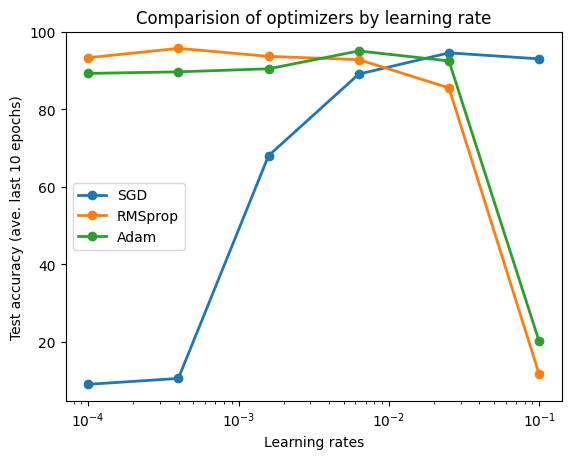

In [14]:
plt.plot(learningRates, finalPerformance, 'o-', linewidth=2)
plt.legend(optimTypes)
plt.xscale('log')
plt.xlabel('Learning rates')
plt.ylabel('Test accuracy (ave. last 10 epochs)')
plt.title('Comparision of optimizers by learning rate')
plt.show()